In [ ]:
!pip install geopy

🚀 데이터 로드 및 통합 작업을 시작합니다...
✅ 기본 데이터 병합 완료: 총 51개 정거장
⏳ 공간 데이터 분석 중... (상가 및 타슈 밀집도 계산)
✅ 종합 등급 산출 완료
⏳ 신규 역 후보지 탐색 중...


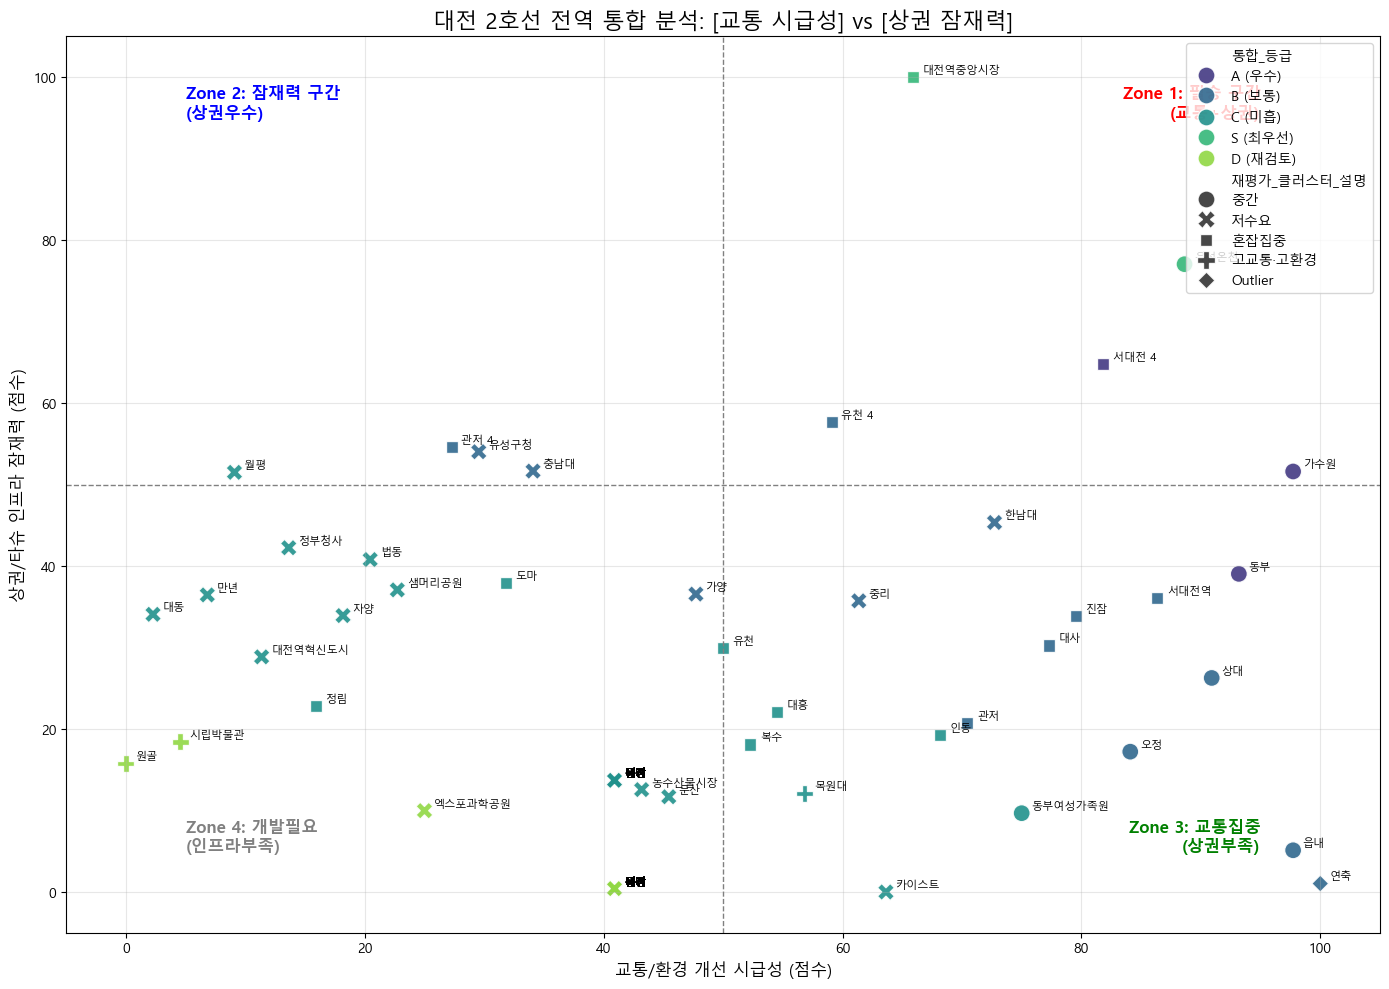

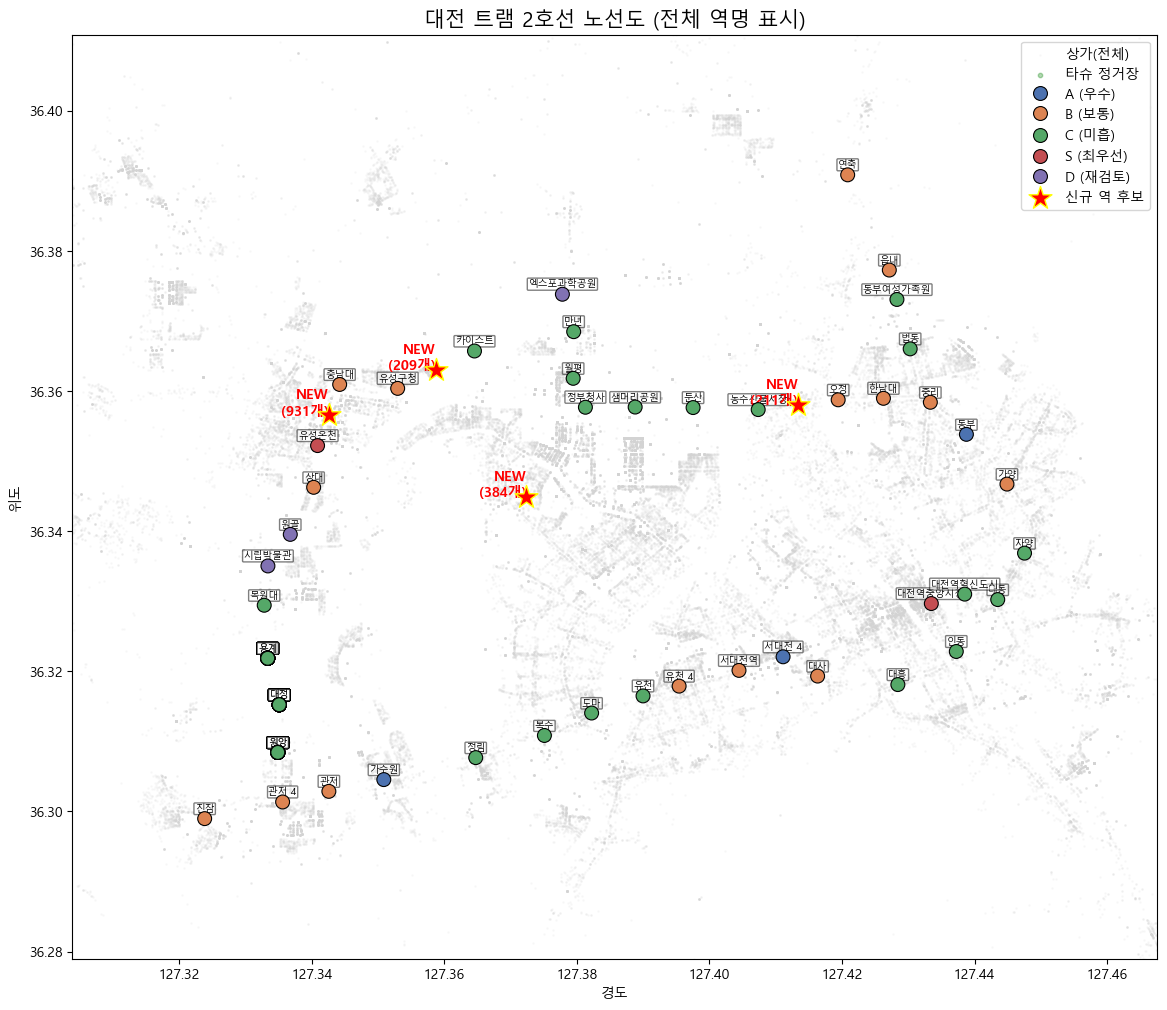


📊 [통합 분석 리포트 Summary]

🏆 최우선 관리 정거장 (S등급: 교통해결+상권활성)
   정거장명   통합_등급  500m_상가수  300m_타슈수
대전역중앙시장 S (최우선)      1934         0
   유성온천 S (최우선)      1490         0

🚀 신규 역 설치 제안 (기존 역 간격 1km 이상 & 상권 밀집)
       구간  300m_상가수
 충남대-유성온천       931
    연축-진잠       384
오정-농수산물시장       211
카이스트-유성구청       209


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic
import platform

# =============================================================================
# 1. 환경 설정 및 데이터 로드
# =============================================================================

# 한글 폰트 설정
system_name = platform.system()
if system_name == 'Darwin': plt.rc('font', family='AppleGothic')
elif system_name == 'Windows': plt.rc('font', family='Malgun Gothic')
else: plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("🚀 데이터 로드 및 통합 작업을 시작합니다...")

# 파일 로드 (파일명 정확히 매칭)
# 1) 기존 분석 결과 (교통/환경)
traffic_result = pd.read_csv(r"C:\Users\popma\OneDrive\문서\카카오톡 받은 파일\대전2호선_최종분석_재평가클러스터포함.csv")
traffic_detail = pd.read_csv(r"C:\Users\popma\OneDrive\문서\카카오톡 받은 파일\대전2호선_정거장별_상세지표.csv")

# 2) 위치 정보 및 Raw Data
station_geo = pd.read_csv(r"C:\Users\popma\Downloads\smart_city\2호선_위_경도.csv")
shop_df = pd.read_csv(r"C:\Users\popma\Downloads\smart_city\소상공인시장진흥공단_상가(상권)정보_대전_202510.csv")
tashu_df = pd.read_csv(r"C:\Users\popma\Downloads\smart_city\tashu_station_info_all.csv")

# =============================================================================
# 2. 데이터 전처리 및 병합 (Master Table 생성)
# =============================================================================

# 정거장명 공백 제거 (매칭 오류 방지)
traffic_result['정거장명'] = traffic_result['정거장명'].str.strip()
station_geo['정거장명'] = station_geo['정거장명'].str.strip()

# 1차 병합: [분석결과] + [상세지표] + [위경도]
# 교통/환경 분석 결과에 좌표를 입힙니다.
master_df = pd.merge(traffic_result, traffic_detail[['정거장ID', '추정교통량', '혼잡빈도강도', 'CO2']], on='정거장ID', how='left')
master_df = pd.merge(master_df, station_geo[['정거장명', '위도', '경도']], on='정거장명', how='left')

print(f"✅ 기본 데이터 병합 완료: 총 {len(master_df)}개 정거장")

# =============================================================================
# 3. 공간 분석 로직 구현 (`버스_상권_타슈.ipynb` 로직 이식)
# =============================================================================
# 각 정거장 좌표를 기준으로 반경 N미터 내 상가/타슈 개수를 직접 카운팅합니다.

print("⏳ 공간 데이터 분석 중... (상가 및 타슈 밀집도 계산)")

# 결과를 담을 리스트
spatial_data = []

# 속도 향상을 위해 대전 지역 상가만 필터링 (이미 대전 파일이지만 안전장치)
daejeon_shops = shop_df[shop_df['시도명'].str.contains('대전', na=False)]

for idx, row in master_df.iterrows():
    center = (row['위도'], row['경도'])
    
    # 3-1. 반경 500m 내 상가 수 (상권 활력도)
    # 위경도 사각 범위로 1차 필터링 (연산 속도 최적화)
    lat_min, lat_max = row['위도'] - 0.005, row['위도'] + 0.005
    lon_min, lon_max = row['경도'] - 0.006, row['경도'] + 0.006
    
    nearby_shops_candidates = daejeon_shops[
        (daejeon_shops['위도'].between(lat_min, lat_max)) & 
        (daejeon_shops['경도'].between(lon_min, lon_max))
    ]
    
    shop_count = 0
    food_cafe_count = 0 # 음식점/카페 (유동인구 핵심)
    
    for _, shop in nearby_shops_candidates.iterrows():
        if geodesic(center, (shop['위도'], shop['경도'])).meters <= 500:
            shop_count += 1
            if '음식' in str(shop['상권업종대분류명']):
                food_cafe_count += 1
                
    # 3-2. 반경 300m 내 타슈 정거장 수 (연계성)
    tashu_count = 0
    # 타슈 데이터 컬럼명 확인: x_pos(경도), y_pos(위도)
    nearby_tashu_candidates = tashu_df[
        (tashu_df['y_pos'].between(lat_min, lat_max)) & 
        (tashu_df['x_pos'].between(lon_min, lon_max))
    ]
    
    for _, bike in nearby_tashu_candidates.iterrows():
        if geodesic(center, (bike['y_pos'], bike['x_pos'])).meters <= 300:
            tashu_count += 1
            
    spatial_data.append({
        '정거장ID': row['정거장ID'],
        '500m_상가수': shop_count,
        '500m_음식점수': food_cafe_count,
        '300m_타슈수': tashu_count
    })

# 분석 결과를 마스터 데이터에 결합
spatial_df = pd.DataFrame(spatial_data)
final_df = pd.merge(master_df, spatial_df, on='정거장ID', how='left')

# =============================================================================
# 4. 종합 등급 산출 (기존 CSV 지표 + 신규 공간 지표 결합)
# =============================================================================
# 점수 산식: (교통혼잡도 정규화 * 0.4) + (상권/타슈 정규화 * 0.6)

def normalize(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

# 교통 시급성 점수 (순위가 낮을수록 시급하므로 역산)
final_df['Score_Traffic'] = normalize(46 - final_df['최종_종합_순위'])

# 상권 잠재력 점수 (상가수 + 타슈 가중치)
final_df['Raw_Potential'] = final_df['500m_상가수'] + (final_df['300m_타슈수'] * 50)
final_df['Score_Potential'] = normalize(final_df['Raw_Potential'])

# 통합 등급 부여 (S, A, B, C, D)
final_df['Total_Score'] = (final_df['Score_Traffic'] * 0.4) + (final_df['Score_Potential'] * 0.6)

def get_grade(score):
    if score >= 80: return 'S (최우선)'
    elif score >= 60: return 'A (우수)'
    elif score >= 40: return 'B (보통)'
    elif score >= 20: return 'C (미흡)'
    else: return 'D (재검토)'

final_df['통합_등급'] = final_df['Total_Score'].apply(get_grade)

print("✅ 종합 등급 산출 완료")

# =============================================================================
# 5. 신규 역 후보지 발굴 (Gap Analysis)
# =============================================================================
print("⏳ 신규 역 후보지 탐색 중...")

candidates = []
# 정거장 ID 순으로 정렬
sorted_stations = final_df.sort_values('정거장ID').reset_index(drop=True)

for i in range(len(sorted_stations) - 1):
    st1 = sorted_stations.iloc[i]
    st2 = sorted_stations.iloc[i+1]
    
    # 두 역 사이 거리 계산
    dist = geodesic((st1['위도'], st1['경도']), (st2['위도'], st2['경도'])).meters
    
    # 거리가 1km 이상 벌어져 있는 경우 중간 지점 분석
    if dist >= 1000:
        mid_lat = (st1['위도'] + st2['위도']) / 2
        mid_lon = (st1['경도'] + st2['경도']) / 2
        
        # 중간 지점 반경 300m 상가 수 카운트
        nearby_mid = daejeon_shops[
            (daejeon_shops['위도'].between(mid_lat-0.003, mid_lat+0.003)) & 
            (daejeon_shops['경도'].between(mid_lon-0.004, mid_lon+0.004))
        ]
        
        cnt = 0
        for _, s in nearby_mid.iterrows():
            if geodesic((mid_lat, mid_lon), (s['위도'], s['경도'])).meters <= 300:
                cnt += 1
                
        # 상가가 200개 이상이면 후보지로 선정
        if cnt >= 200:
            candidates.append({
                '구간': f"{st1['정거장명']}-{st2['정거장명']}",
                '위도': mid_lat,
                '경도': mid_lon,
                '300m_상가수': cnt
            })

candidates_df = pd.DataFrame(candidates)
if not candidates_df.empty:
    candidates_df = candidates_df.sort_values('300m_상가수', ascending=False)

# =============================================================================
# 6. 결과 시각화 (모든 역 이름 표시 버전)
# =============================================================================

# [Figure 1] 통합 매트릭스 분석 (교통 vs 상권)
plt.figure(figsize=(14, 10)) # 그래프 크기를 좀 더 키웠습니다

# 산점도 그리기
sns.scatterplot(
    data=final_df, 
    x='Score_Traffic', y='Score_Potential',
    hue='통합_등급', 
    palette='viridis', 
    style='재평가_클러스터_설명',
    s=150, alpha=0.9
)

# 중앙선 (기준선)
plt.axvline(x=50, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=50, color='gray', linestyle='--', linewidth=1)

# 텍스트 라벨링 (모든 역 표시)
# 겹침 방지를 위해 zip 함수 사용 및 조건문 제거
for i, row in final_df.iterrows():
    plt.text(
        x=row['Score_Traffic'] + 0.8,  # 점보다 오른쪽으로 0.8만큼 이동
        y=row['Score_Potential'] + 0.5,  # 점보다 위로 0.5만큼 이동
        s=row['정거장명'], 
        fontsize=8,       # 모든 역을 표시하므로 글자 크기를 8로 축소
        color='black',
        weight='normal'   # 글자 두께 보통
    )

# 4분면 설명 텍스트
plt.text(x=95, y=95, s="Zone 1: 필승 구간\n(교통+상권)", fontsize=12, color='red', ha='right', weight='bold')
plt.text(x=5, y=95, s="Zone 2: 잠재력 구간\n(상권우수)", fontsize=12, color='blue', ha='left', weight='bold')
plt.text(x=95, y=5, s="Zone 3: 교통집중\n(상권부족)", fontsize=12, color='green', ha='right', weight='bold')
plt.text(x=5, y=5, s="Zone 4: 개발필요\n(인프라부족)", fontsize=12, color='gray', ha='left', weight='bold')

plt.title('대전 2호선 전역 통합 분석: [교통 시급성] vs [상권 잠재력]', fontsize=16)
plt.xlabel('교통/환경 개선 시급성 (점수)', fontsize=12)
plt.ylabel('상권/타슈 인프라 잠재력 (점수)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# [Figure 2] 지도 시각화 (기존 역 + 신규 후보 + 타슈)
# (이 부분은 이전과 동일하게 유지)
plt.figure(figsize=(14, 12))

# 1. 배경: 전체 상권
plt.scatter(daejeon_shops['경도'], daejeon_shops['위도'], c='lightgray', s=1, alpha=0.1, label='상가(전체)')

# 2. 타슈 스테이션
plt.scatter(tashu_df['x_pos'], tashu_df['y_pos'], c='green', s=10, alpha=0.3, label='타슈 정거장')

# 3. 기존 트램 정거장
sns.scatterplot(
    data=final_df, x='경도', y='위도', 
    hue='통합_등급', palette='deep', s=100, edgecolor='black', zorder=5
)

# 기존 역 이름 모두 표시 (지도상)
for i, row in final_df.iterrows():
    plt.text(
        x=row['경도'], 
        y=row['위도'] + 0.001, # 지도상 위치보다 살짝 위
        s=row['정거장명'], 
        fontsize=7, 
        ha='center',
        bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.5) # 가독성을 위해 흰 배경 추가
    )

# 4. 신규 후보지
if not candidates_df.empty:
    plt.scatter(candidates_df['경도'], candidates_df['위도'], 
               c='red', marker='*', s=300, edgecolor='yellow', label='신규 역 후보', zorder=10)
    
    for _, row in candidates_df.iterrows():
        plt.text(row['경도'], row['위도'], f"NEW\n({row['300m_상가수']}개)", 
                 fontsize=10, fontweight='bold', color='red', ha='right')

plt.title('대전 트램 2호선 노선도 (전체 역명 표시)', fontsize=15)
plt.legend(loc='upper right')
plt.xlim(final_df['경도'].min()-0.02, final_df['경도'].max()+0.02)
plt.ylim(final_df['위도'].min()-0.02, final_df['위도'].max()+0.02)
plt.grid(False)
plt.show()

# =============================================================================
# 7. 텍스트 결과 출력
# =============================================================================
print("\n" + "="*50)
print("📊 [통합 분석 리포트 Summary]")
print("="*50)
print("\n🏆 최우선 관리 정거장 (S등급: 교통해결+상권활성)")
print(final_df[final_df['통합_등급']=='S (최우선)'][['정거장명', '통합_등급', '500m_상가수', '300m_타슈수']].to_string(index=False))

print("\n🚀 신규 역 설치 제안 (기존 역 간격 1km 이상 & 상권 밀집)")
if not candidates_df.empty:
    print(candidates_df[['구간', '300m_상가수']].to_string(index=False))
else:
    print("조건을 만족하는 신규 후보지가 없습니다.")

In [3]:
# =============================================================================
# 8. QGIS 구현을 위한 데이터 내보내기 (Export)
# =============================================================================
print("\n💾 QGIS용 데이터 저장을 시작합니다...")

# 1) 기존 정거장 분석 결과 저장 (통합 등급 및 좌표 포함)
# QGIS에서 한글 깨짐 방지를 위해 'utf-8-sig' 또는 'cp949' 인코딩 사용
final_df.to_csv(r"C:\Users\popma\Downloads/QGIS_01_기존정거장_분석결과.csv", index=False, encoding='utf-8-sig')

# 2) 신규 후보지 데이터 저장
if not candidates_df.empty:
    candidates_df.to_csv(r"C:\Users\popma\Downloads/QGIS_02_신규후보지_제안.csv", index=False, encoding='utf-8-sig')

# 3) 상가/타슈 원본 데이터도 필요하다면 저장 (배경으로 깔기 위해)
# (이미 파일이 있으므로 생략해도 되지만, 전처리된 데이터가 필요하면 아래 주석 해제)
# daejeon_shops.to_csv("QGIS_03_대전_상가_전처리.csv", index=False, encoding='utf-8-sig')

print("✅ 파일 저장 완료! 생성된 CSV 파일들을 QGIS에서 열어보세요.")


💾 QGIS용 데이터 저장을 시작합니다...
✅ 파일 저장 완료! 생성된 CSV 파일들을 QGIS에서 열어보세요.
